In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [62]:
df = pd.read_csv('financial_loan_data.csv')

In [63]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2/11/2021,9/13/2021,4/13/2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,1/1/2021,12/14/2021,1/15/2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,1/5/2021,12/12/2021,1/9/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2/25/2021,12/12/2021,3/12/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,1/1/2021,12/14/2021,1/15/2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [66]:
#Segregate customers on the basis of features

In [70]:
features = ['annual_income','dti','int_rate','loan_amount']

In [72]:
df_cleaned = df[features].dropna()

In [74]:
df_cleaned

,annual_income,dti,int_rate,loan_amount
0,30000.0,0.0100,0.1527,2500
1,48000.0,0.0535,0.1864,3000
2,50000.0,0.2088,0.1596,12000
3,42000.0,0.0540,0.1065,4500
4,83000.0,0.0231,0.0603,3500
...,...,...,...,...
38571,100000.0,0.1986,0.1299,24250
38572,50000.0,0.0458,0.1349,25200
38573,65000.0,0.1734,0.1749,25000
38574,368000.0,0.0009,0.1825,24000


In [78]:
scaler = StandardScaler()


In [80]:
X_train_scale = scaler.fit_transform(df_cleaned)

In [82]:
X_train_scale

array([[-0.61662443, -1.84928078,  0.86675273, -1.17899481],
       [-0.33665549, -1.19672227,  1.77355304, -1.11197652],
       [-0.30554783,  1.13298662,  1.05241808,  0.0943528 ],
       ...,
       [-0.07224039,  0.601939  ,  1.4641108 ,  1.83682848],
       [ 4.64056999, -1.98579302,  1.66861176,  1.70279189],
       [ 0.16106706, -1.09921352,  2.40589154,  0.89857234]])

In [84]:
error_rate = []
k_range = range(1,21)


In [86]:
for i in k_range:
    kmeans = KMeans(n_clusters = i, random_state =42)
    kmeans.fit(X_train_scale)
    error_rate.append(kmeans.inertia_)

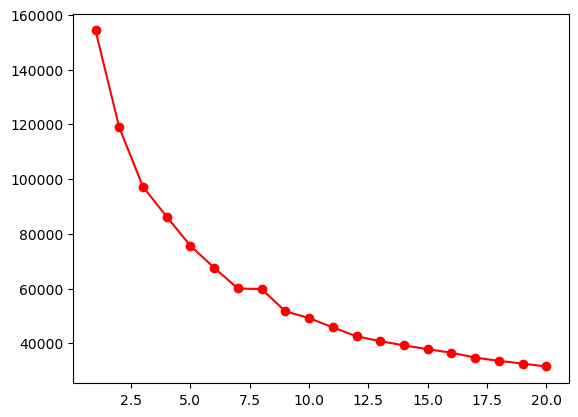

In [87]:
plt.plot(k_range,error_rate,marker='o',color = 'red')

In [88]:
k = 3
model = KMeans(n_clusters = k ,random_state = 42)

In [92]:
clusters = model.fit_predict(X_train_scale)

In [94]:
df_cleaned['Clusters'] = clusters

In [96]:
df_cleaned

,annual_income,dti,int_rate,loan_amount,Clusters
0,30000.0,0.0100,0.1527,2500,0
1,48000.0,0.0535,0.1864,3000,0
2,50000.0,0.2088,0.1596,12000,2
3,42000.0,0.0540,0.1065,4500,0
4,83000.0,0.0231,0.0603,3500,0
...,...,...,...,...,...
38571,100000.0,0.1986,0.1299,24250,1
38572,50000.0,0.0458,0.1349,25200,1
38573,65000.0,0.1734,0.1749,25000,1
38574,368000.0,0.0009,0.1825,24000,1


<Axes: xlabel='annual_income', ylabel='loan_amount'>

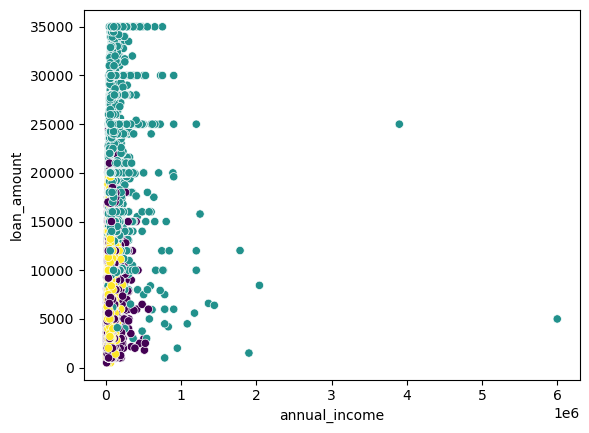

In [98]:
sns.scatterplot(data = df_cleaned , x= 'annual_income' ,y='loan_amount',c = clusters)